In [25]:
import os

from dotenv import load_dotenv

load_dotenv()

os.environ['OPENAI_API_KEY'] = os.getenv('OPENAI_API_KEY')

In [26]:
from typing import TypedDict, Optional


class AgentState(TypedDict):
     """Shared state that flows through all nodes in the graph."""

     Location: str
     monthly_bill: int
     roof_type: list[str]
     shading: str
     battery_intrest: str
     Primary_goal: str

     research_notes: Optional[str]
     draft_quoting: Optional[str]

     final_quote: Optional[str]
    
print("Agent state defined")

Agent state defined


In [27]:
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(
    model = "gpt-4.1-nano",
    temperature=0,
)

print(f"LLM initialized {llm}")

LLM initialized profile={'max_input_tokens': 1047576, 'max_output_tokens': 32768, 'image_inputs': True, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True, 'structured_output': True, 'image_url_inputs': True, 'pdf_inputs': True, 'pdf_tool_message': True, 'image_tool_message': True, 'tool_choice': True} client=<openai.resources.chat.completions.completions.Completions object at 0x00000236BB9F2780> async_client=<openai.resources.chat.completions.completions.AsyncCompletions object at 0x00000236BB9C3E90> root_client=<openai.OpenAI object at 0x00000236BB90ABD0> root_async_client=<openai.AsyncOpenAI object at 0x00000236BB9F0FE0> model_name='gpt-4.1-nano' temperature=0.0 model_kwargs={} openai_api_key=SecretStr('**********') stream_usage=True


In [28]:
from langchain_core.messages import HumanMessage, SystemMessage

def research_node(state: AgentState) -> AgentState:
    """Analyze the product and extract research insights."""

    print("Research node is running...")

    roof_type = "\n".join(f"  - {f}" for f in state['roof_type'])

    messages = [
        SystemMessage(content=(
           """You are SolarBot, a solar energy advisor for SolarEdge Pro.

Your task is to convert structured, pre-calculated solar quote data into a clear, accurate, and personalized summary for the homeowner.

Strict Rules:
- Use ONLY the provided data
- Do NOT calculate, estimate, or modify any values
- Do NOT add assumptions or extra information
- If a field is missing, omit it (do not guess)

Style Guidelines:
- Professional, friendly, and easy to understand
- Avoid technical jargon unless necessary
- Focus on benefits, clarity, and readability

Output Format:
- Write a short personalized summary (2–4 sentences)
- Then provide a clean bullet list of key details"""
        )),

        HumanMessage(content=(
f"""
Generate a solar quote summary for this client using ONLY the provided data. Do not change, recalculate, or reinterpret any numeric values.
Location: {state['Location']}
Monthly Bill: ${state['monthly_bill']}$
Roof Type: {state['roof_type']}
Shading: {state['shading']}
Battery Interest: {state['battery_intrest']}
Primary Goal: {state["Primary_goal"] },

Generate the solar quote summary following the required format.
"""
        ))
    ]

    response = llm.invoke(messages)
    print("✅ Research complete.")
    return {**state, "research_notes": response.content}

print("✅ research note identified")

✅ research note identified


In [29]:
def draft_node(state: AgentState) -> AgentState:
    """Write a first draft of the product description using research notes."""
    print("Draft node is running....")
    
    roof_value = state["roof_type"] if isinstance(state["roof_type"], str) else ", ".join(state["roof_type"])


    messages = [
        SystemMessage(
            content=(
                "You are an expert solar quoting copywriter for SimkoSolar Energy. "
                "Your job is to write short, high-converting solar estimate messages that immediately grab attention. "
                "The reader should notice the most important information in the first few lines: "
                "their location, current bill, main goal, and estimated 25-year savings. "
                "Write like a real solar consultant speaking clearly to a homeowner. "
                "Be specific, warm, trustworthy, and concise. "
                "Do not sound robotic, generic, or overly salesy. "
                "Do not overload the message with explanations. "
                "Focus only on the information most likely to make the reader interested in the quote."
                ""
            )
        ),
        HumanMessage(
            content=f"""
Write a solar quote message for SimkoSolar Energy.

Customer details:
Location: {state['Location']}
Monthly Bill: {state['monthly_bill']}$
Roof Type: {roof_value}
Shading: {state['shading']}
Battery Interest: {state['battery_intrest']}
Primary Goal: {state['Primary_goal']}

Research notes:
{state.get('research_notes', '')}

Instructions:
Write a short quote message that makes the most important information stand out immediately.

Prioritize this order:
1. Mention the customer's location and monthly bill early.
2. State the estimated 25-year savings as early as possible if available in the research notes.
3. Connect the estimate directly to the customer's main goal of lowering electricity bills.
4. Briefly mention roof type and shading only as supporting context, not as the main focus.
5. Reassure the customer that final numbers may vary based on site conditions.

Writing rules:
- Keep it between 800 - 1200 words.
- Use plain conversational text only.
- No markdown, no bullet points, no headings, no symbols like checkmarks or emojis.
- Keep paragraphs short and easy to skim.
- The first 2 sentences must contain the most attention-grabbing information.
- Clearly say the numbers are estimates based on the information provided.
- Do not invent numbers, percentages, or technical details.
- Do not add new facts not already given in the state or research notes.
- Keep the tone warm, confident, honest, and professional.
- You have to give an estimate and specific number of 25 years saving to them always between 2 amounts

"""
        )
    ]
    response = llm.invoke(messages)
    print(f"Draft completed {response}")

    return {**state, "draft_quoting": response.content}

print("✅ draft_node defined")


✅ draft_node defined


In [30]:
def refine_node(state: AgentState) -> AgentState:
    """Polish and optimize the solar quote draft."""

    print("Refine node is running....")

    roof_value = state["roof_type"] if isinstance(state["roof_type"], str) else ", ".join(state["roof_type"])

    messages = [
        SystemMessage(
            content=(
                "You are a senior solar quoting editor for SimkoSolar Energy. "
                "Your job is to refine draft solar estimate messages so they are clear, persuasive, trustworthy, and easy to read. "
                "Keep the strongest value-driving information early, especially anything related to savings and lowering electricity bills. "
                "Do not make the message longer than necessary. "
                "Do not invent facts, savings numbers, percentages, or technical details. "
                "Only improve clarity, flow, readability, and sales impact while staying faithful to the original draft and provided information."
            )
        ),
        HumanMessage(
            content=f"""
Review and refine this solar quote message so it is customer-ready.

Customer goal:
{state["Primary_goal"]}

Draft to refine:
{state["draft_quoting"]}

Requirements:
- Keep it plain conversational text only.
- No markdown, no bullet points, no headings, no emojis.
- Keep the most important customer-facing information near the beginning.
- Make sure it clearly supports the customer's goal: {state["Primary_goal"]}.
- Clearly state that all figures are estimates based on the information provided.
- Mention that shading, roof type, and location may affect final installation results.
- Do not add new facts.
- Do not change or invent numbers.
- Keep the tone warm, honest, professional, and encouraging.
- Make it feel polished, natural, and easy to skim.
- Keep it concise.

If the draft already includes a 25-year savings estimate range (a range that have at least 10% in between no more than that), 
preserve it naturally in the message.


and output like this:

location: {state['Location']}

monthly_bill: {state['monthly_bill']}$

roof type: {roof_value}

goal: {state['Primary_goal']}

shading: {state['shading']}

battery_intrest: {state['battery_intrest']}

primary goal: {state['Primary_goal']}

estimates 25 years saving: write the estimates 25 years savign here
"""
        )
    ]

    response = llm.invoke(messages)

    print("Refinement complete")
    return {**state, "final_quote": response.content}

print("✅ refine_node defined")

✅ refine_node defined


In [31]:
from langgraph.graph import START, END, StateGraph


builder = StateGraph(AgentState)

builder.add_node("research", research_node)
builder.add_node("draft", draft_node)
builder.add_node("refine", refine_node)


builder.add_edge(START,    "research")
builder.add_edge("research", "draft")
builder.add_edge("draft", "refine")
builder.add_edge("refine", END)

agent = builder.compile()

print("✅ LangGraph compiled successfully!")
print("\nGraph flow: START → research → draft → refine → END")


✅ LangGraph compiled successfully!

Graph flow: START → research → draft → refine → END


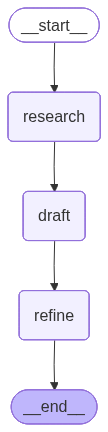

In [32]:
# Visualize the graph structure (requires graphviz)
try:
    from IPython.display import Image, display
    display(Image(agent.get_graph().draw_mermaid_png()))
except Exception:
    # Fallback: print Mermaid diagram code
    print(agent.get_graph().draw_mermaid())

In [33]:
product_input: AgentState = {
    "Location": "10001 (New york)",
    "monthly_bill": 180,
    "roof_type": ["flat"],
    "shading": "no shading",
    "battery_intrest": "no",
    "Primary_goal": "Lower the Electricity bills",


    "research_notes": None,
    "draft_quoting": None,
    "final_quote": None
}

print("✅ Product input ready. Running agent...\n")
print("=" * 60)


result = agent.invoke(product_input)
print("=" * 60)
print("\n🎉 Agent complete!")

✅ Product input ready. Running agent...

Research node is running...
✅ Research complete.
Draft node is running....
Draft completed content='Hi! Based on your location in 10001, New York, and your current monthly bill of $180, I’ve prepared an estimate showing you could save approximately $40,000 to $50,000 over the next 25 years by switching to solar. Your main goal is to lower those electricity costs, and with a flat roof and no shading, your home is an ideal fit for solar panels to perform at their best. \n\nPlease keep in mind, these numbers are estimates based on the information you provided, and final savings may vary depending on actual site conditions. I’d love to help you take the next step toward reducing your bills and making a smart, long-term investment in your home.' additional_kwargs={'refusal': None} response_metadata={'token_usage': {'completion_tokens': 141, 'prompt_tokens': 552, 'total_tokens': 693, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audi

In [34]:
from IPython.display import Markdown, display

# ── Research Notes ──
print("=" * 60)
print("🔍 RESEARCH NOTES")
print("=" * 60)
display(Markdown(result["research_notes"]))

🔍 RESEARCH NOTES


Based on your location in New York and your goal to lower electricity bills, this solar solution is designed to help you save on energy costs. Since your roof is flat and there is no shading, it provides an ideal setup for optimal solar panel performance. Additionally, the system does not include a battery, focusing solely on reducing your monthly electricity expenses.

Key Details:
- Location: 10001, New York
- Monthly Electricity Bill: $180
- Roof Type: Flat
- Shading: None
- Battery: Not included
- Primary Goal: Lower electricity bills

In [35]:
from IPython.display import Markdown, display

# ── Research Notes ──
print("=" * 60)
print("🔍 Draft")
print("=" * 60)
display(Markdown(result["draft_quoting"]))

🔍 Draft


Hi! Based on your location in 10001, New York, and your current monthly bill of $180, I’ve prepared an estimate showing you could save approximately $40,000 to $50,000 over the next 25 years by switching to solar. Your main goal is to lower those electricity costs, and with a flat roof and no shading, your home is an ideal fit for solar panels to perform at their best. 

Please keep in mind, these numbers are estimates based on the information you provided, and final savings may vary depending on actual site conditions. I’d love to help you take the next step toward reducing your bills and making a smart, long-term investment in your home.

In [36]:
from IPython.display import Markdown, display

# ── Research Notes ──
print("=" * 60)
print("🔍 Draft")
print("=" * 60)
display(Markdown(result["final_quote"]))

🔍 Draft


location: 10001 (New York)  
monthly_bill: 180$  
roof type: flat  
goal: Lower the Electricity bills  
shading: no shading  
battery_interest: no  
primary goal: Lower the Electricity bills  

Based on your current monthly bill of $180, I’ve prepared an estimate showing you could save approximately $40,000 to $50,000 over the next 25 years by switching to solar. Since your roof is flat and has no shading, it’s an ideal fit for solar panels to perform at their best.  

Please remember, these figures are estimates based on the information you provided, and actual savings may vary depending on site conditions. I’d be happy to help you take the next step toward reducing your bills and making a smart, long-term investment in your home.